In [2]:
from jax import random, numpy as jnp
from lqg import xcorr
from lqg.belief import kf
import matplotlib.pyplot as plt

from cppp.models.multisensory import MultisensoryDelayModel, BiasMultisensoryDelayModel, MultisensoryDelayModelPointMassDynamics, SubjectiveMultisensoryDelayModelPointMassDynamics, BiasMultisensoryDelayModelPointMassDynamics, BiasMultisensoryDelayModel


In [3]:
params = {"action_cost": 0.05, "m": 1., "tau": 0.066, "dt": 0.075, "delays": [1], "T": 1000, "action_variability": 0.1, "process_noise": 1.0, "sigmas": [1.0]}

force_model = MultisensoryDelayModelPointMassDynamics(
    **params
)

subj_model = SubjectiveMultisensoryDelayModelPointMassDynamics(
        subj_process_noise=1.,
        subj_vel_process_noise=1.,
        **params
)

bias_model = BiasMultisensoryDelayModelPointMassDynamics(
        **params
)


(20, 12, 4)
(20, 12, 4)
(20, 12, 4)


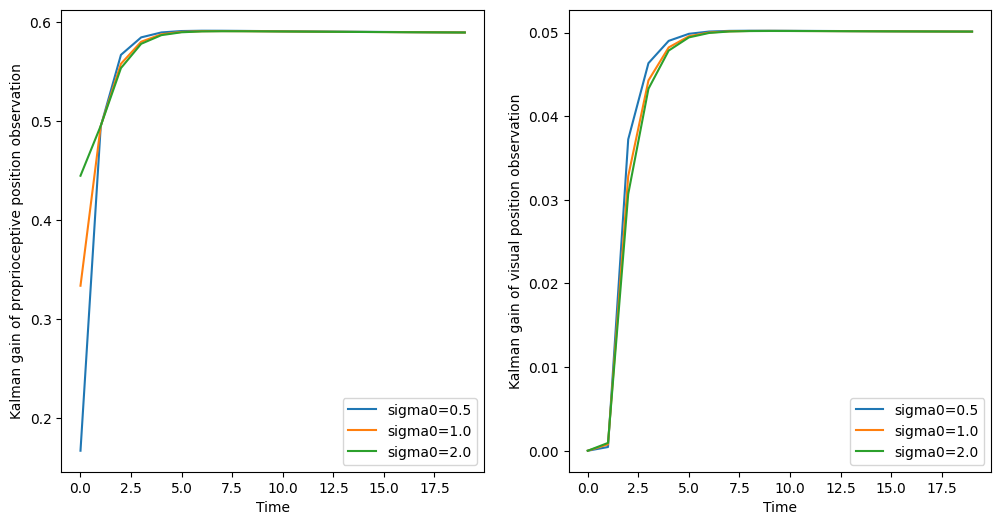

In [24]:
sigma_vis_values = jnp.array([0.5, 1.0, 2.0])

f, ax = plt.subplots(1, 2, figsize=(12, 6))
for sigma0 in sigma_vis_values:
    params = {"action_cost": 0.05, "m": 1., "tau": 0.066, "dt": 0.075, "delays": [1, 2], "T": 20, "action_variability": 0.1, "process_noise": 1.0, "sigmas": [1.0, 2.0],}


    force_model = MultisensoryDelayModelPointMassDynamics(
        **params, 
    )

    K = kf.forward(force_model.actor, Sigma0=sigma0 ** 2 * jnp.eye(force_model.xdim))
    print(K.shape)

    ax[0].plot(K[:, 0, 0], label=f"sigma0={sigma0}")
    ax[1].plot(K[:, 0, 2], label=f"sigma0={sigma0}")
ax[0].set_ylabel("Kalman gain of proprioceptive position observation")
ax[0].set_xlabel("Time")
ax[1].set_ylabel("Kalman gain of visual position observation")
ax[1].set_xlabel("Time")
ax[0].legend()
ax[1].legend()
plt.show()

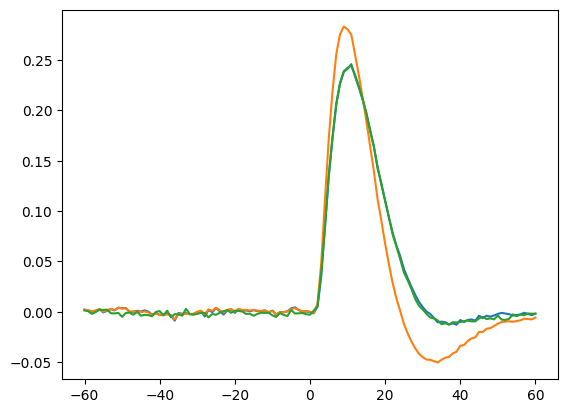

In [3]:
for model in [force_model, subj_model, bias_model]:
    key = random.PRNGKey(0)
    x = model.simulate(key, n=100)
    print(model)
    vels = jnp.diff(x, axis=-2)
    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=60)

    plt.plot(lags, correls.mean(axis=0))

In [25]:
for bias in [0.0, 1.0, 2., 3., 4., 5.]:
    for i, vis_noise in enumerate([4., 12.]):
        delays = dict(vis=2, prop=1)
        bias_model = BiasMultisensoryDelayModelPointMassDynamics(sigmas=[2., vis_noise], T=168, action_variability=0.09, action_cost=1e-5, delays=[1, 2])
        print(bias_model.xdim)
        key = random.PRNGKey(0)
        x = bias_model.simulate(key, n=100, x0=jnp.array([0.0] * (bias_model.xdim // 2 - 1) + [bias] + [0.0] * (bias_model.xdim // 2)))
        error = x[..., 0] - x[..., 1]

        plt.scatter(bias, error.mean(), label=f"bias={bias}", color=f"C{i}")

15


TypeError: dot_general requires contracting dimensions to have the same shape, got (15,) and (14,).